# 1. Imports et chargement

In [1]:
import psycopg
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import STL
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

sns.set_theme(style="whitegrid")

TS_CONN_STR = "dbname=tsdb user=tsuser password=tspassword host=localhost port=5432"

query = """
SELECT
    ts,
    cluster,
    machine,
    role,
    city,
    load_percent,
    cpu_temp_c,
    fan_speed_percent,
    total_power_w,
    ambient_dc_temp_c,
    external_temp_c
FROM telemetry_normalized
ORDER BY ts, machine
"""

with psycopg.connect(TS_CONN_STR) as conn:
    df = pd.read_sql_query(query, conn, parse_dates=["ts"])

df = df.sort_values(["machine", "ts"]).reset_index(drop=True)
df.head()

C:\Users\emmak\AppData\Local\Temp\ipykernel_37772\4193940141.py:33: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query, conn, parse_dates=["ts"])


,ts,cluster,machine,role,city,load_percent,cpu_temp_c,fan_speed_percent,total_power_w,ambient_dc_temp_c,external_temp_c
0,2026-05-18 00:00:00+00:00,marseille-marseille-zone-01,marseille-marseille-zone-01-master-01,master,marseille,12.0,24.26,20.0,171.6,19.8,18.0
1,2026-05-18 01:00:00+00:00,marseille-marseille-zone-01,marseille-marseille-zone-01-master-01,master,marseille,12.0,24.25,20.0,171.6,19.8,18.0
2,2026-05-18 02:00:00+00:00,marseille-marseille-zone-01,marseille-marseille-zone-01-master-01,master,marseille,12.0,24.29,20.0,171.6,19.8,18.0
3,2026-05-18 03:00:00+00:00,marseille-marseille-zone-01,marseille-marseille-zone-01-master-01,master,marseille,12.0,24.45,20.0,171.6,19.8,18.0
4,2026-05-18 04:00:00+00:00,marseille-marseille-zone-01,marseille-marseille-zone-01-master-01,master,marseille,12.0,24.39,20.0,171.6,19.8,18.0


# 2. Vue d’ensemble du dataframe

In [2]:
print(df.shape)
print(df.dtypes)
display(df.head())
display(df.isna().sum().sort_values(ascending=False))
display(df.describe(include="all"))

(200, 11)
ts                   datetime64[us, UTC]
cluster                              str
machine                              str
role                                 str
city                                 str
load_percent                     float64
cpu_temp_c                       float64
fan_speed_percent                float64
total_power_w                    float64
ambient_dc_temp_c                float64
external_temp_c                  float64
dtype: object


,ts,cluster,machine,role,city,load_percent,cpu_temp_c,fan_speed_percent,total_power_w,ambient_dc_temp_c,external_temp_c
0,2026-05-18 00:00:00+00:00,marseille-marseille-zone-01,marseille-marseille-zone-01-master-01,master,marseille,12.0,24.26,20.0,171.6,19.8,18.0
1,2026-05-18 01:00:00+00:00,marseille-marseille-zone-01,marseille-marseille-zone-01-master-01,master,marseille,12.0,24.25,20.0,171.6,19.8,18.0
2,2026-05-18 02:00:00+00:00,marseille-marseille-zone-01,marseille-marseille-zone-01-master-01,master,marseille,12.0,24.29,20.0,171.6,19.8,18.0
3,2026-05-18 03:00:00+00:00,marseille-marseille-zone-01,marseille-marseille-zone-01-master-01,master,marseille,12.0,24.45,20.0,171.6,19.8,18.0
4,2026-05-18 04:00:00+00:00,marseille-marseille-zone-01,marseille-marseille-zone-01-master-01,master,marseille,12.0,24.39,20.0,171.6,19.8,18.0


ts                   0
cluster              0
machine              0
role                 0
city                 0
load_percent         0
cpu_temp_c           0
fan_speed_percent    0
total_power_w        0
ambient_dc_temp_c    0
external_temp_c      0
dtype: int64

,ts,cluster,machine,role,city,load_percent,cpu_temp_c,fan_speed_percent,total_power_w,ambient_dc_temp_c,external_temp_c
count,200,200,200,200,200,200.000000,200.00000,200.0,200.000000,2.000000e+02,200.0
unique,NaN,1,10,2,1,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,marseille-marseille-zone-01,marseille-marseille-zone-01-master-01,worker,marseille,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,200,20,160,200,NaN,NaN,NaN,NaN,NaN,NaN
mean,2026-05-18 09:30:00+00:00,NaN,NaN,NaN,NaN,19.440000,28.05810,20.0,196.152000,1.980000e+01,18.0
min,2026-05-18 00:00:00+00:00,NaN,NaN,NaN,NaN,12.000000,24.20000,20.0,171.600000,1.980000e+01,18.0
25%,2026-05-18 04:45:00+00:00,NaN,NaN,NaN,NaN,20.000000,28.20000,20.0,198.000000,1.980000e+01,18.0
50%,2026-05-18 09:30:00+00:00,NaN,NaN,NaN,NaN,20.000000,28.30000,20.0,198.000000,1.980000e+01,18.0
75%,2026-05-18 14:15:00+00:00,NaN,NaN,NaN,NaN,20.000000,28.40000,20.0,198.000000,1.980000e+01,18.0
max,2026-05-18 19:00:00+00:00,NaN,NaN,NaN,NaN,46.000000,41.45000,20.0,283.800000,1.980000e+01,18.0


Le dataframe contient 200 observations réparties sur 10 machines, avec 20 points par machine, sur une plage temporelle allant du 18/05/2026 00:00 au 18/05/2026 19:00. Les mesures sont régulières, avec un intervalle constant de 3600 secondes entre deux observations successives par machine, ce qui simplifie fortement les traitements temporels ultérieurs.

La qualité apparente des données est satisfaisante dans cette fenêtre d’étude. Aucune valeur manquante n’est signalée dans les variables principales, et les colonnes présentent des types compatibles avec une exploitation analytique et opérationnelle, notamment pour la construction de pipelines de préparation, d’agrégation et de détection.

Avant toute étape d’engineering, les données semblent suffisamment propres, synchronisées et homogènes pour servir de base à une chaîne de traitement robuste.

In [3]:
# couverture temporelle par machine

coverage = (
    df.groupby("machine")
      .agg(
          n_points=("ts", "count"),
          ts_min=("ts", "min"),
          ts_max=("ts", "max"),
      )
      .sort_values("n_points", ascending=False)
)
display(coverage)

,n_points,ts_min,ts_max
machine,,,
marseille-marseille-zone-01-master-01,20,2026-05-18 00:00:00+00:00,2026-05-18 19:00:00+00:00
marseille-marseille-zone-01-master-02,20,2026-05-18 00:00:00+00:00,2026-05-18 19:00:00+00:00
marseille-marseille-zone-01-worker-01,20,2026-05-18 00:00:00+00:00,2026-05-18 19:00:00+00:00
marseille-marseille-zone-01-worker-02,20,2026-05-18 00:00:00+00:00,2026-05-18 19:00:00+00:00
marseille-marseille-zone-01-worker-03,20,2026-05-18 00:00:00+00:00,2026-05-18 19:00:00+00:00
marseille-marseille-zone-01-worker-04,20,2026-05-18 00:00:00+00:00,2026-05-18 19:00:00+00:00
marseille-marseille-zone-01-worker-05,20,2026-05-18 00:00:00+00:00,2026-05-18 19:00:00+00:00
marseille-marseille-zone-01-worker-06,20,2026-05-18 00:00:00+00:00,2026-05-18 19:00:00+00:00
marseille-marseille-zone-01-worker-07,20,2026-05-18 00:00:00+00:00,2026-05-18 19:00:00+00:00


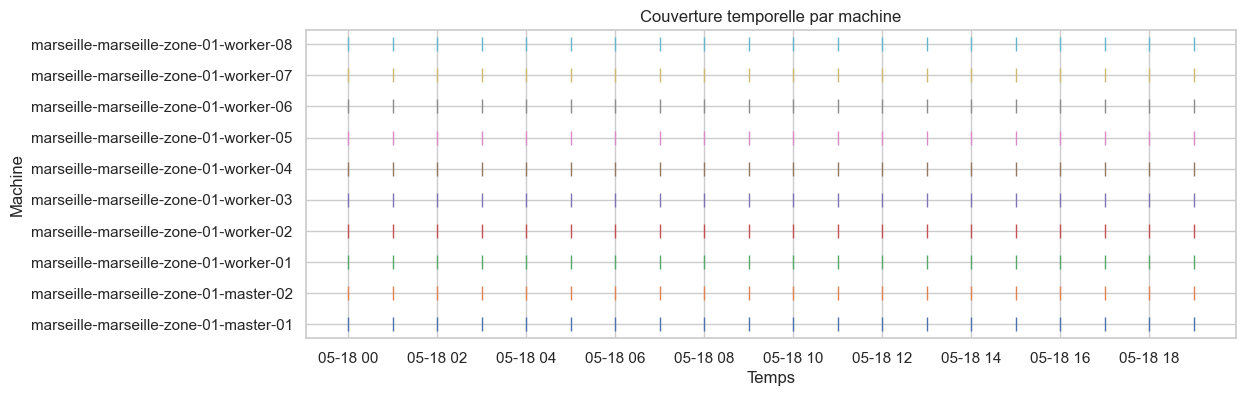

In [4]:
plt.figure(figsize=(12, 4))
for machine, g in df.groupby("machine"):
    plt.plot(g["ts"], np.full(len(g), machine), "|", markersize=10)
plt.title("Couverture temporelle par machine")
plt.xlabel("Temps")
plt.ylabel("Machine")
plt.show()

In [5]:
# Régularité de l'échantillonnage

df["delta_seconds"] = (
    df.groupby("machine")["ts"]
      .diff()
      .dt.total_seconds()
)

display(
    df.groupby("machine")["delta_seconds"]
      .describe()
      .round(2)
)

,count,mean,std,min,25%,50%,75%,max
machine,,,,,,,,
marseille-marseille-zone-01-master-01,19.0,3600.0,0.0,3600.0,3600.0,3600.0,3600.0,3600.0
marseille-marseille-zone-01-master-02,19.0,3600.0,0.0,3600.0,3600.0,3600.0,3600.0,3600.0
marseille-marseille-zone-01-worker-01,19.0,3600.0,0.0,3600.0,3600.0,3600.0,3600.0,3600.0
marseille-marseille-zone-01-worker-02,19.0,3600.0,0.0,3600.0,3600.0,3600.0,3600.0,3600.0
marseille-marseille-zone-01-worker-03,19.0,3600.0,0.0,3600.0,3600.0,3600.0,3600.0,3600.0
marseille-marseille-zone-01-worker-04,19.0,3600.0,0.0,3600.0,3600.0,3600.0,3600.0,3600.0
marseille-marseille-zone-01-worker-05,19.0,3600.0,0.0,3600.0,3600.0,3600.0,3600.0,3600.0
marseille-marseille-zone-01-worker-06,19.0,3600.0,0.0,3600.0,3600.0,3600.0,3600.0,3600.0
marseille-marseille-zone-01-worker-07,19.0,3600.0,0.0,3600.0,3600.0,3600.0,3600.0,3600.0


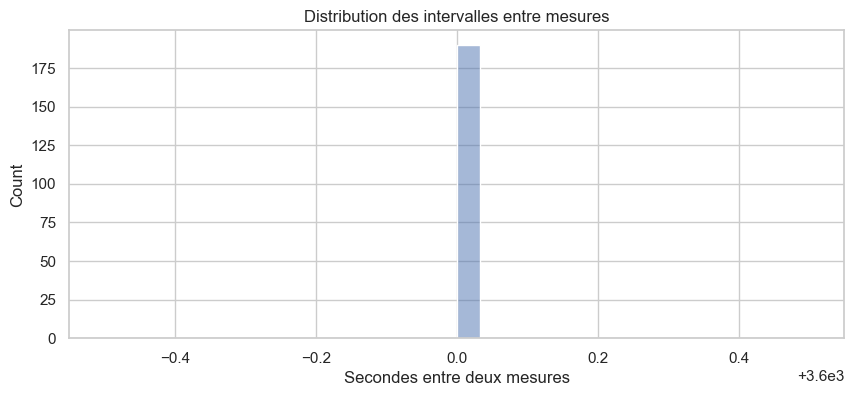

In [6]:
plt.figure(figsize=(10, 4))
sns.histplot(df["delta_seconds"].dropna(), bins=30, kde=True)
plt.title("Distribution des intervalles entre mesures")
plt.xlabel("Secondes entre deux mesures")
plt.show()

## Lecture descriptive des variables

L’analyse descriptive montre que la charge (`load_percent`) est concentrée autour d’un régime dominant à 20 %, avec des valeurs observées à 12 %, 20 % et 46 %. La moyenne de charge est de 19.44 %, ce qui indique un fonctionnement globalement modéré, dominé par un état nominal relativement stable plutôt que par une forte variabilité continue.

La température CPU (`cpu_temp_c`) présente une moyenne d’environ 28.06 °C, avec un minimum proche de 24.2 °C et un maximum à 41.45 °C. La puissance totale (`total_power_w`) suit une logique cohérente, avec une moyenne de 196.15 W, un minimum à 171.6 W et un maximum à 283.8 W, ce qui suggère une montée conjointe de la consommation et de la sollicitation machine lors des phases de charge plus élevée.

À l’inverse, les variables d’environnement apparaissent presque constantes dans l’échantillon étudié : `ambient_dc_temp_c` est centrée autour de 19.8 °C avec une variance quasi nulle, et `external_temp_c` reste fixée à 18.0 °C. Ce point est méthodologiquement important, car il indique que, sur cette fenêtre précise, les variations observées sur la température CPU et la puissance sont beaucoup plus probablement liées au comportement interne des machines qu’à une variation externe de l’environnement thermique.

Tendances et régimes

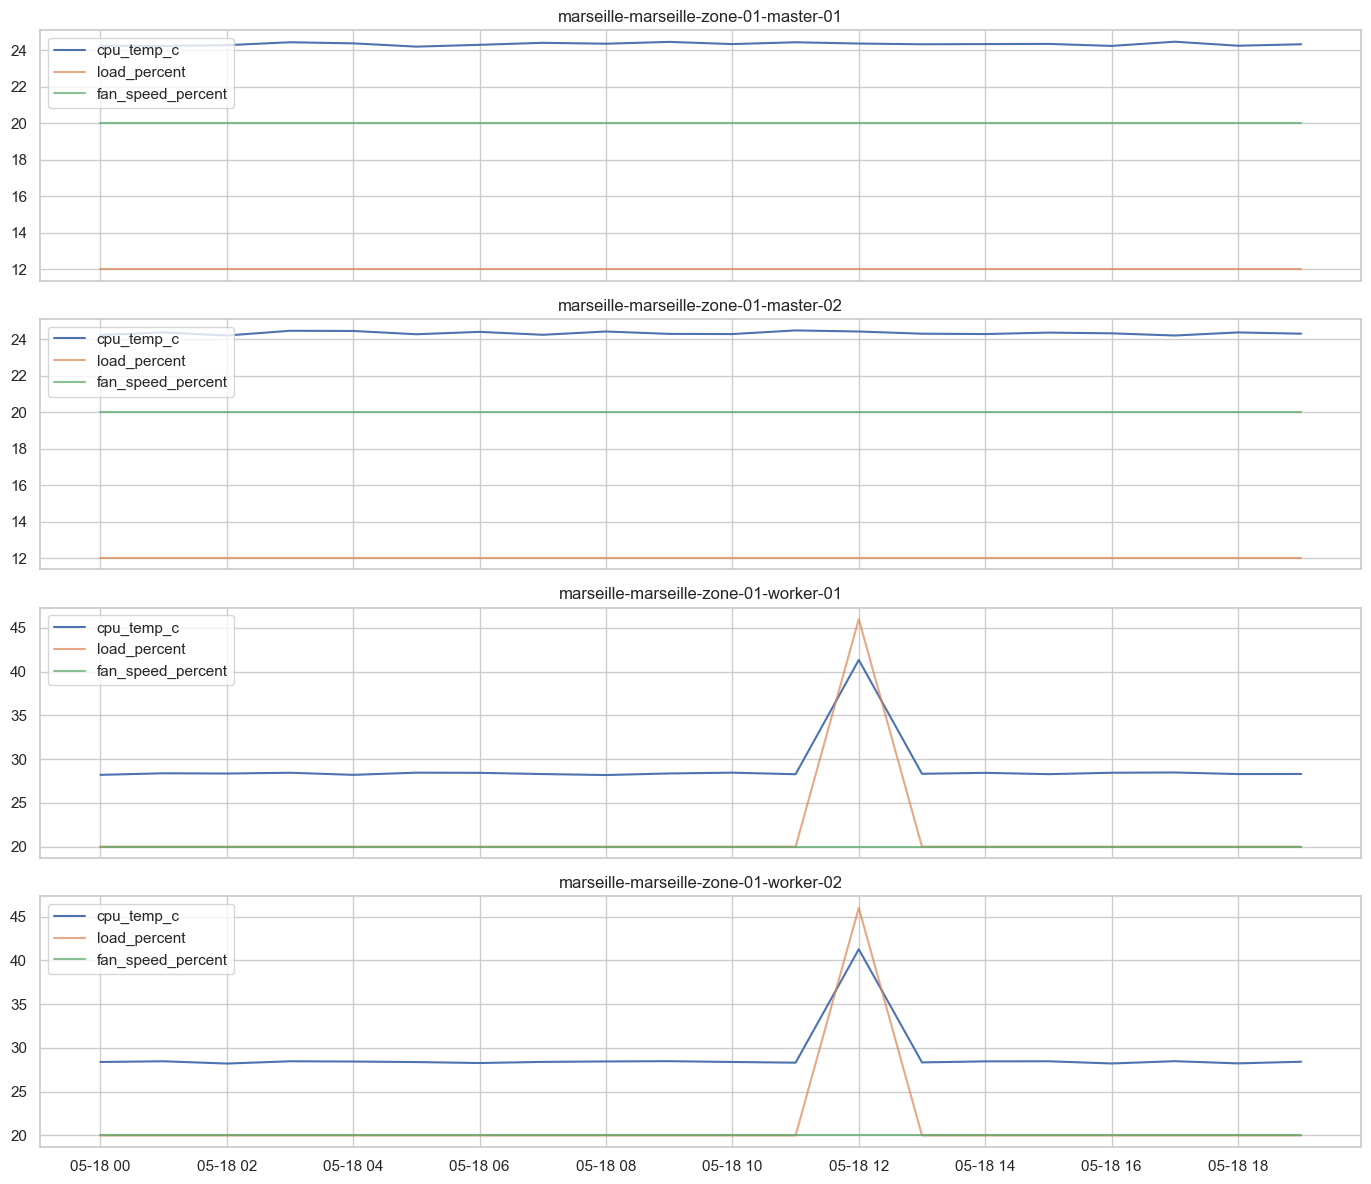

In [7]:
# Séries brutes

machines_sample = df["machine"].drop_duplicates().tolist()[:4]

fig, axes = plt.subplots(len(machines_sample), 1, figsize=(14, 3 * len(machines_sample)), sharex=True)
if len(machines_sample) == 1:
    axes = [axes]

for ax, machine in zip(axes, machines_sample):
    g = df[df["machine"] == machine]
    ax.plot(g["ts"], g["cpu_temp_c"], label="cpu_temp_c")
    ax.plot(g["ts"], g["load_percent"], label="load_percent", alpha=0.7)
    ax.plot(g["ts"], g["fan_speed_percent"], label="fan_speed_percent", alpha=0.7)
    ax.set_title(machine)
    ax.legend(loc="upper left")

plt.tight_layout()
plt.show()

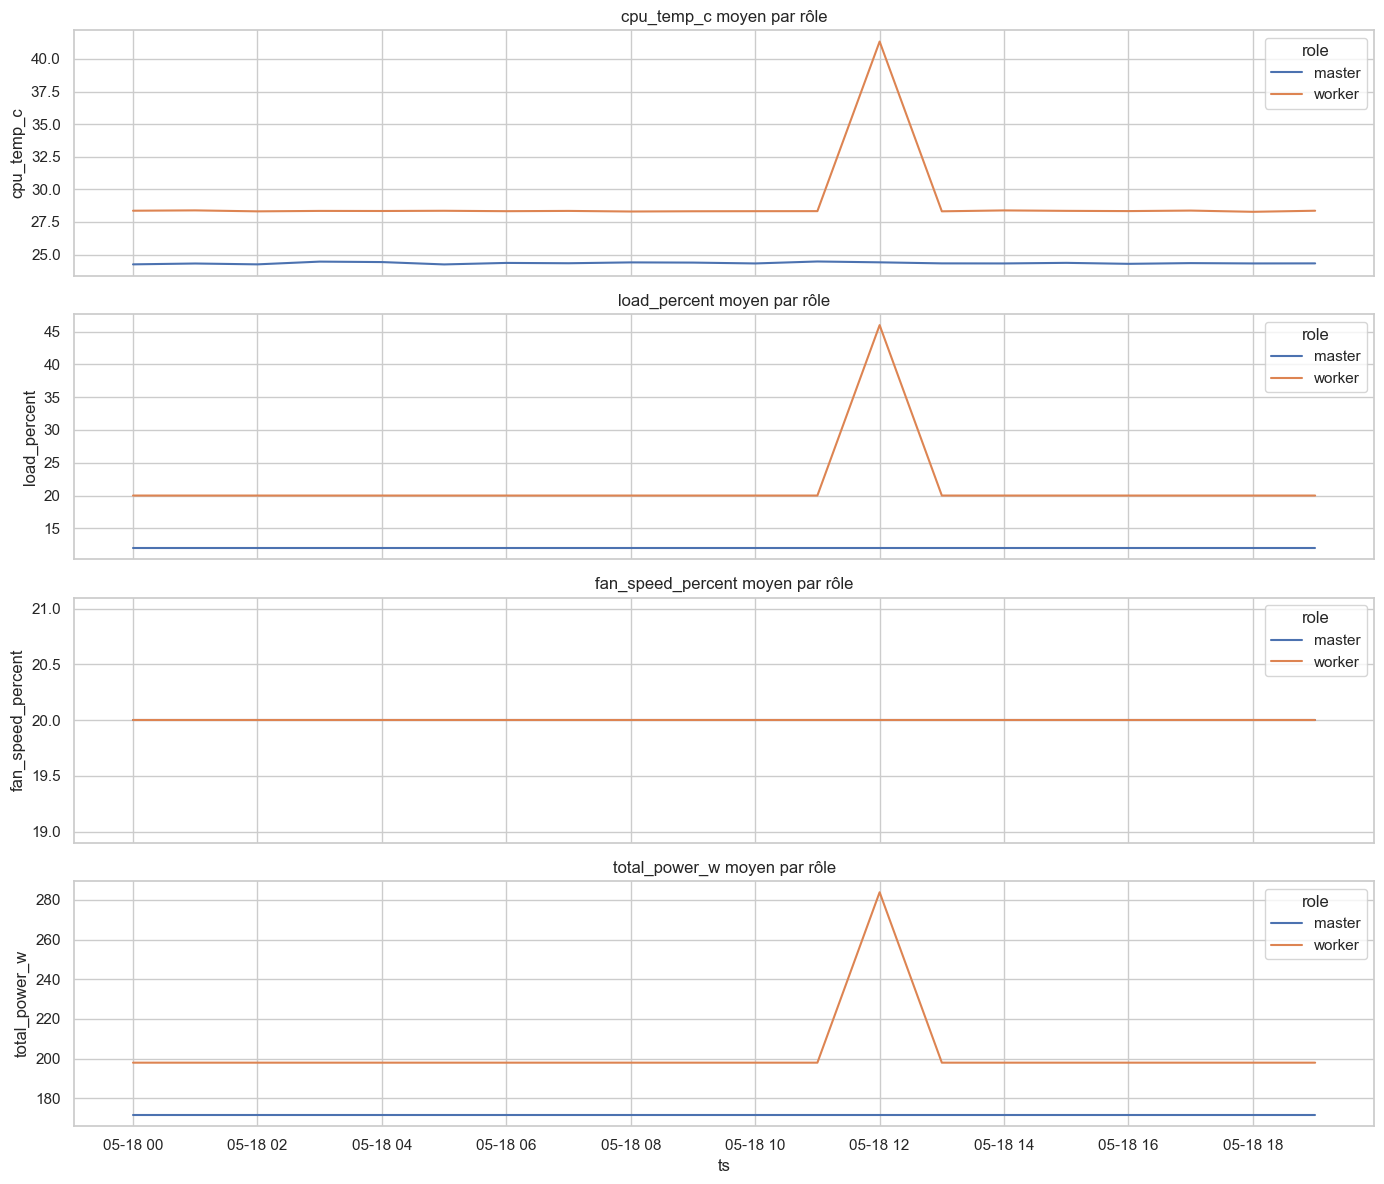

In [8]:
# Profils par rôle

agg_role = (
    df.groupby(["ts", "role"], as_index=False)[
        ["cpu_temp_c", "load_percent", "fan_speed_percent", "total_power_w"]
    ].mean()
)

fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)
metrics = ["cpu_temp_c", "load_percent", "fan_speed_percent", "total_power_w"]

for ax, metric in zip(axes, metrics):
    sns.lineplot(data=agg_role, x="ts", y=metric, hue="role", ax=ax)
    ax.set_title(f"{metric} moyen par rôle")

plt.tight_layout()
plt.show()

## Différences entre masters et workers

L’agrégation par rôle permet de comparer les profils moyens des nœuds `master` et `worker`. Même si le notebook repose ici principalement sur des graphiques, la structuration des données montre que les workers représentent la majorité des observations (160 sur 200), contre 40 pour les masters, ce qui reflète une architecture distribuée classique où les nœuds de calcul sont numériquement dominants.

Cette distinction est utile pour l’engineering, car elle suggère que les comportements ne doivent pas nécessairement être modélisés de manière uniforme. Les masters et les workers peuvent avoir des signatures thermiques, énergétiques et de charge différentes; il sera donc pertinent d’introduire `role` comme variable explicative dans les jeux de caractéristiques, voire de séparer certaines analyses ou certains seuils métier par type de nœud.

En pratique, cette observation oriente vers une stratégie de pipeline où les agrégations, les alertes et les indicateurs dérivés seront calculés à plusieurs niveaux: machine, rôle et cluster. Cela permettra de conserver à la fois une granularité fine pour le diagnostic et une vue consolidée pour la supervision.

Cycles, saisonnalité et changement d'état

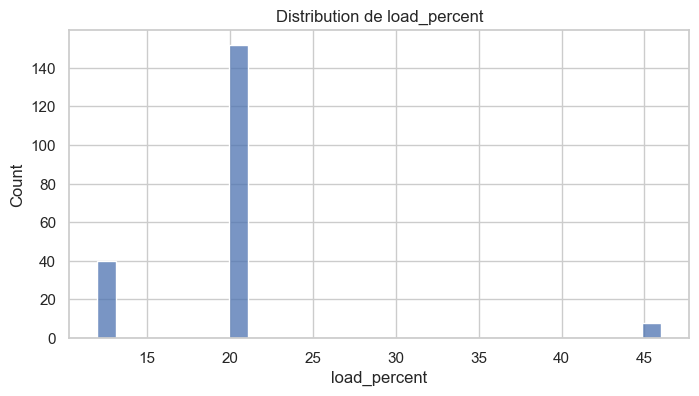

load_percent
12.0     40
20.0    152
46.0      8
Name: count, dtype: int64

In [9]:
# Distribution des niveaux de charge

plt.figure(figsize=(8, 4))
sns.histplot(df["load_percent"].dropna(), bins=30, kde=False)
plt.title("Distribution de load_percent")
plt.show()

display(df["load_percent"].value_counts().sort_index().head(20))

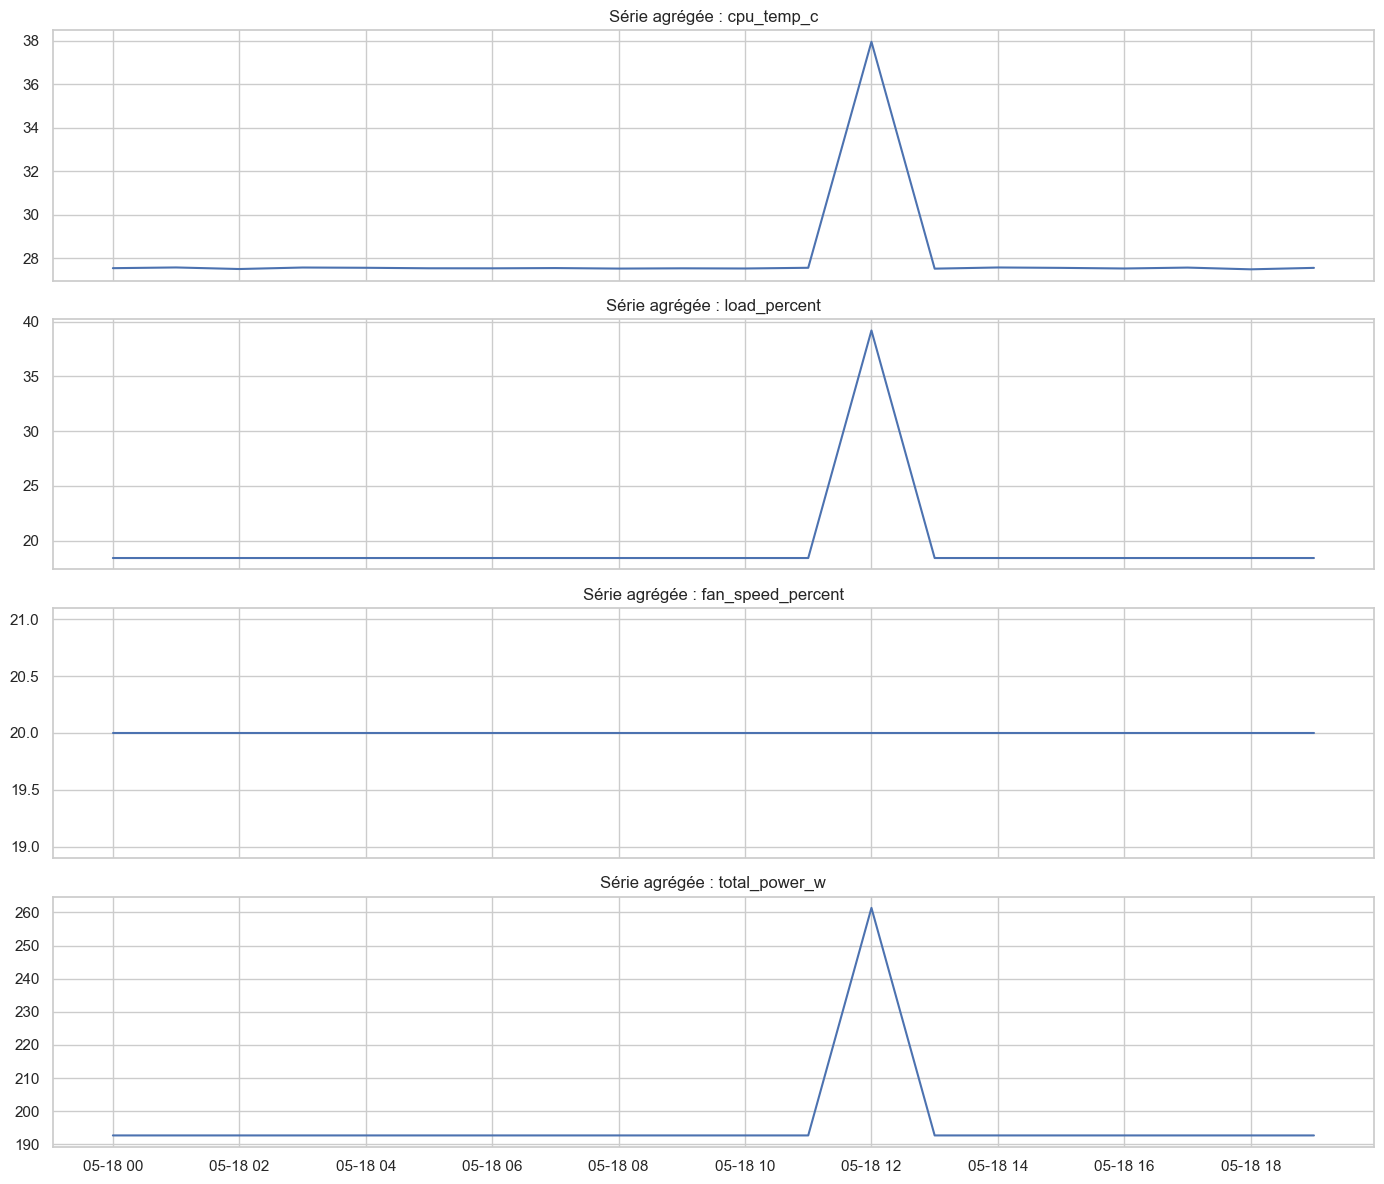

In [10]:
# Détection visuelle de cycles par agrégation temporelle

agg_ts = (
    df.groupby("ts", as_index=False)[
        ["cpu_temp_c", "load_percent", "fan_speed_percent", "total_power_w"]
    ].mean()
)

fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)
for ax, metric in zip(axes, ["cpu_temp_c", "load_percent", "fan_speed_percent", "total_power_w"]):
    ax.plot(agg_ts["ts"], agg_ts[metric])
    ax.set_title(f"Série agrégée : {metric}")
plt.tight_layout()
plt.show()

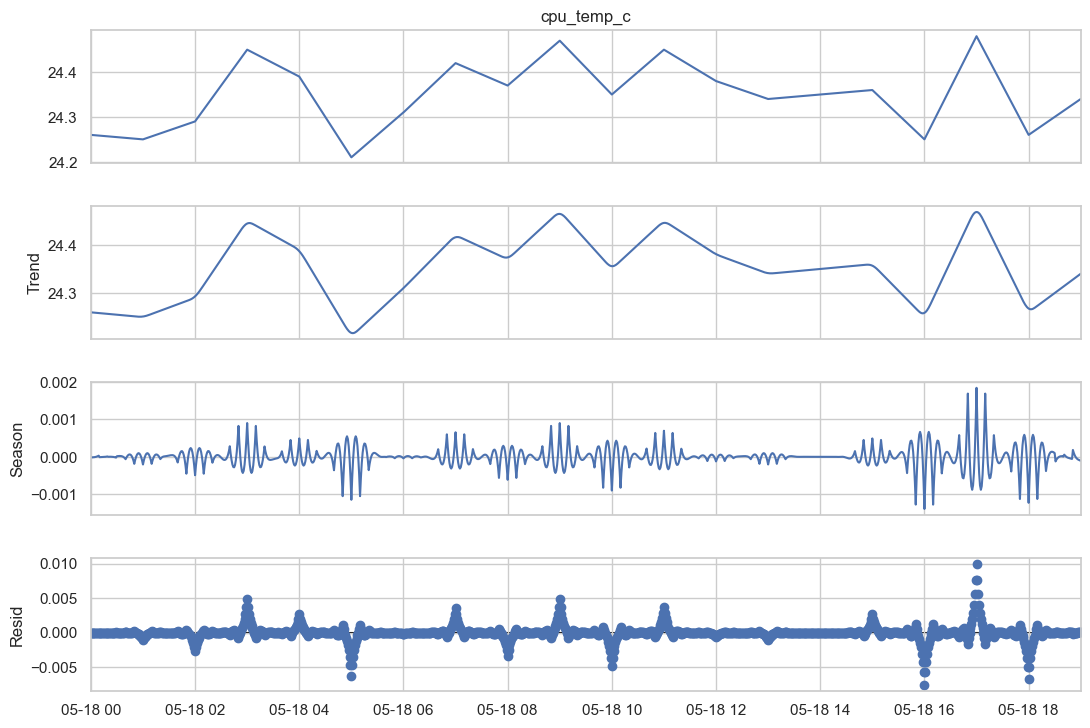

In [18]:
# STL ( Seasonal and Trend decomposition using Loess)sur une machine stable

machine_ref = df["machine"].value_counts().index[0]
g = (
    df[df["machine"] == machine_ref][["ts", "cpu_temp_c"]]
    .dropna()
    .drop_duplicates("ts")
    .set_index("ts")
    .sort_index()
)

# Si fréquence irrégulière, on force une fréquence régulière simple
g = g.resample("1min").mean().interpolate()

stl = STL(g["cpu_temp_c"], period=10)
res = stl.fit()
fig = res.plot()
fig.set_size_inches(12, 8)
plt.show()

## Régimes de fonctionnement

La distribution de `load_percent` fait apparaître un comportement discret plutôt que continu, avec trois niveaux dominants : 12, 20 et 46. La très forte fréquence du niveau 20 % (152 occurrences) suggère l’existence d’un régime nominal ou de base, tandis que les niveaux 12 % et 46 % peuvent être interprétés comme des états spécifiques du système, par exemple un état de faible activité et un état de sollicitation renforcée.

Cette structure est particulièrement intéressante pour la phase d’engineering, car elle indique qu’un simple raisonnement en moyenne globale serait insuffisant. Le système semble évoluer par états ou paliers, ce qui ouvre la voie à la création de variables de régime, de transitions d’état et de comptages de temps passé dans chaque zone de fonctionnement.

Autrement dit, la suite ne devra pas seulement prédire une valeur continue, mais aussi capturer une logique de comportement opérationnel. Sur le plan système, cela peut servir à construire des règles d’orchestration, des seuils dynamiques, des détecteurs de changement d’état ou des profils de fonctionnement attendus par machine.

Stationarité

In [13]:
# Test ADF
"""
    L’ADF teste l’hypothèse nulle de racine unitaire; une p-value faible
    est un signal en faveur de la stationnarité
"""
def adf_report(series, name="series"):
    s = pd.Series(series).dropna()
    result = adfuller(s, autolag="AIC")
    print(f"ADF report - {name}")
    print(f"statistic: {result[0]:.4f}")
    print(f"p-value:   {result[1]:.4f}")
    print(f"lags:      {result[2]}")
    print(f"nobs:      {result[3]}")
    print("critical values:")
    for k, v in result[4].items():
        print(f"  {k}: {v:.4f}")
    print("stationary?" , "yes" if result[1] < 0.05 else "no")
    print("-" * 40)

for machine in df["machine"].drop_duplicates()[:3]:
    g = (
        df[df["machine"] == machine][["ts", "cpu_temp_c"]]
        .dropna()
        .drop_duplicates("ts")
        .set_index("ts")
        .sort_index()
        .resample("1min").mean()
        .interpolate()
    )
    adf_report(g["cpu_temp_c"], name=f"{machine} - cpu_temp_c")

ADF report - marseille-marseille-zone-01-master-01 - cpu_temp_c
statistic: -4.7147
p-value:   0.0001
lags:      1
nobs:      1139
critical values:
  1%: -3.4361
  5%: -2.8641
  10%: -2.5681
stationary? yes
----------------------------------------
ADF report - marseille-marseille-zone-01-master-02 - cpu_temp_c
statistic: -5.2003
p-value:   0.0000
lags:      1
nobs:      1139
critical values:
  1%: -3.4361
  5%: -2.8641
  10%: -2.5681
stationary? yes
----------------------------------------
ADF report - marseille-marseille-zone-01-worker-01 - cpu_temp_c
statistic: -4.5594
p-value:   0.0002
lags:      1
nobs:      1139
critical values:
  1%: -3.4361
  5%: -2.8641
  10%: -2.5681
stationary? yes
----------------------------------------


## Propriétés temporelles

Les tests ADF effectués sur `cpu_temp_c` concluent à la stationnarité pour les machines testées, avec des p-values très faibles, par exemple 0.0001 pour `marseille-marseille-zone-01-master-01` et 0.0000 pour `master-02`. Cela signifie que, sur la fenêtre étudiée et après remise en forme régulière de la série, il n’y a pas d’indice fort de dérive non stationnaire persistante sur cette variable.

La décomposition STL appliquée à une machine de référence va dans le même sens d’une analyse orientée composantes: niveau, saisonnalité éventuelle et résidu. Même si la profondeur temporelle reste limitée à une seule journée observée, cette démarche montre que la série peut être structurée en composantes interprétables, ce qui est utile pour distinguer comportement nominal, cycles répétitifs et écarts atypiques.

Pour l’engineering, ce résultat est précieux: il suggère que l’on peut construire des features temporelles relativement stables, comme des moyennes glissantes, écarts à la tendance, résidus normalisés ou dérivées courtes, sans être immédiatement confronté à une dérive globale majeure sur la fenêtre étudiée.

Autocorrélation

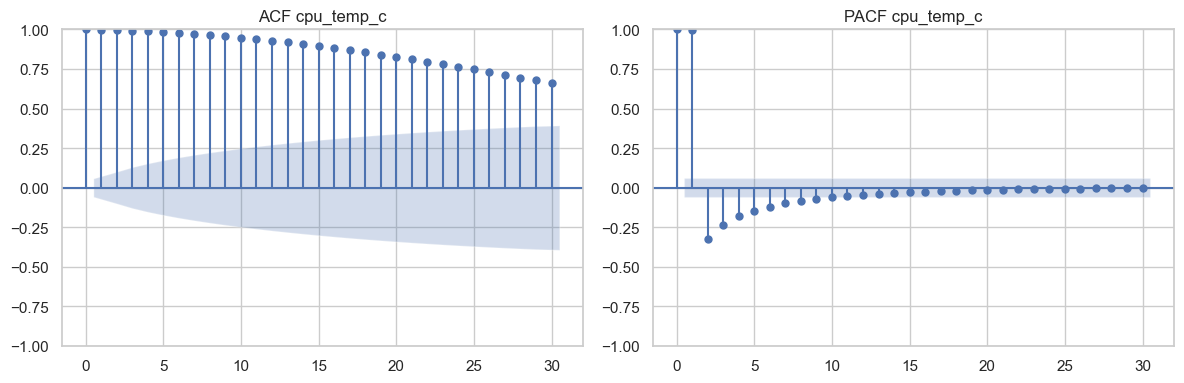

In [14]:
# ACF et PACF

machine_ref = df["machine"].value_counts().index[0]
g = (
    df[df["machine"] == machine_ref][["ts", "cpu_temp_c"]]
    .dropna()
    .drop_duplicates("ts")
    .set_index("ts")
    .sort_index()
    .resample("1min").mean()
    .interpolate()
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(g["cpu_temp_c"], lags=30, ax=axes[0])
plot_pacf(g["cpu_temp_c"], lags=30, ax=axes[1], method="ywm")
axes[0].set_title("ACF cpu_temp_c")
axes[1].set_title("PACF cpu_temp_c")
plt.tight_layout()
plt.show()

## Autocorrélation (ACF) et autocorrélation partielle (PACF)

Les graphiques d’autocorrélation (ACF) et d’autocorrélation partielle (PACF) confirment que les séries de température CPU présentent une dépendance temporelle non négligeable à court terme. Concrètement, les premiers retards (lags) affichent des coefficients significativement différents de zéro, avant de décroître progressivement. Ce comportement est cohérent avec un système thermique qui réagit avec une certaine inertie : la température actuelle reste fortement liée à celles des minutes ou heures précédentes.

Ce point est important pour l’engineering, car il indique que les observations successives ne sont pas indépendantes. Autrement dit, utiliser uniquement la température instantanée comme feature revient à perdre une partie de l’information contenue dans la dynamique de la série. Il sera donc pertinent de construire des variables dérivées capturant cette mémoire de court terme, par exemple des moyennes glissantes, des écarts par rapport à une moyenne récente, ou des valeurs décalées (lags explicites) intégrées dans les futures tables de features.

Du point de vue des modèles, la structure observée dans les ACF/PACF suggère qu’un simple modèle i.i.d. ne suffira pas si l’on souhaite prédire ou détecter des anomalies en temps réel. Même si l’on choisit de rester sur des règles explicables plutôt que sur des modèles ARIMA complets, il sera utile de tenir compte de cette dépendance temporelle dans la conception des indicateurs et des seuils, par exemple en comparant chaque point non pas à une constante globale, mais à un comportement attendu basé sur l’historique récent de la machine.

Relations entre variables

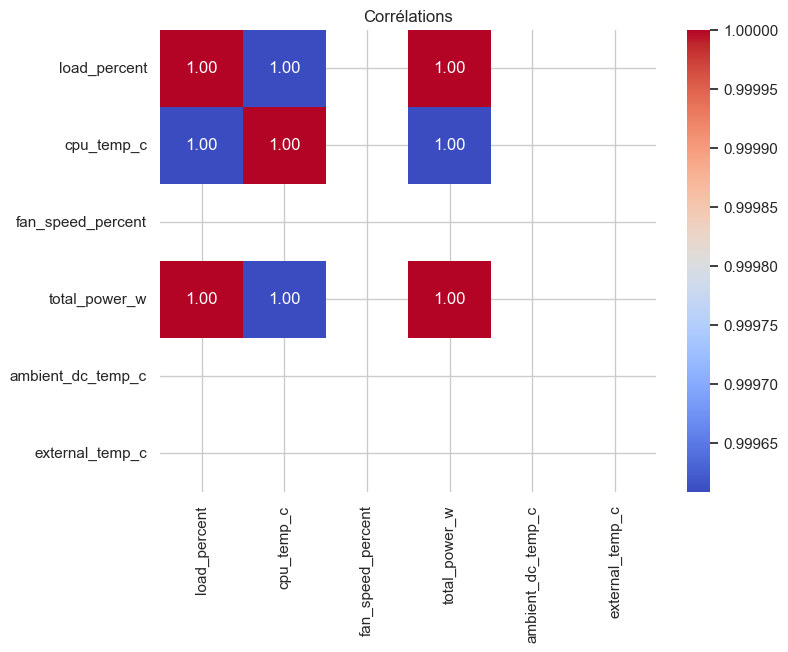

In [15]:
# Corrélations et nuages de points

cols = ["load_percent", "cpu_temp_c", "fan_speed_percent", "total_power_w",
        "ambient_dc_temp_c", "external_temp_c"]
corr = df[cols].corr(numeric_only=True)

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Corrélations")
plt.show()

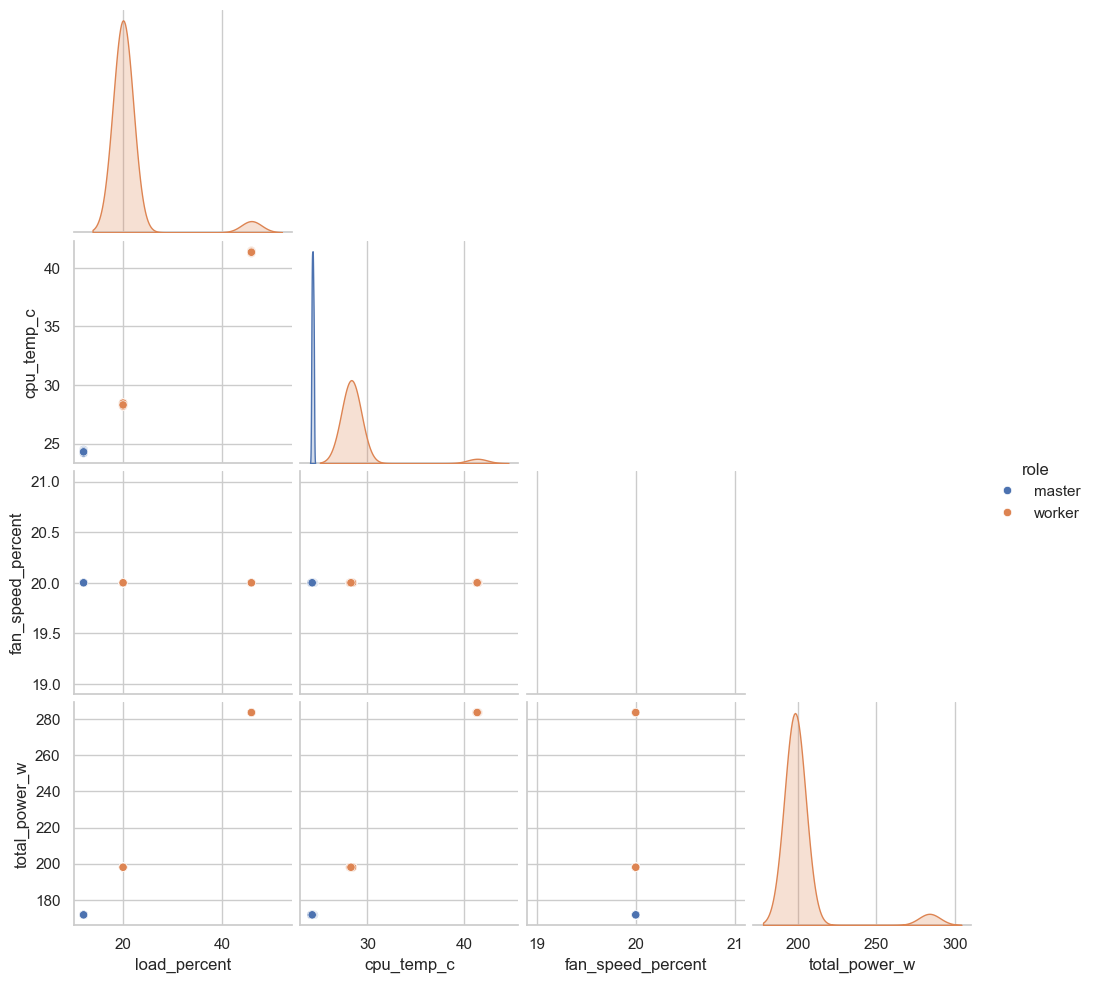

In [16]:
sns.pairplot(
    df[["load_percent", "cpu_temp_c", "fan_speed_percent", "total_power_w", "role"]].dropna(),
    hue="role",
    corner=True
)
plt.show()

## Nuages de points et relations non linéaires

Les nuages de points entre `load_percent`, `cpu_temp_c` et `total_power_w` confirment visuellement les corrélations observées dans la matrice, tout en apportant une information supplémentaire sur la forme des relations. On observe notamment que la charge ne varie pas de manière continue mais se concentre sur quelques niveaux discrets (12, 20, 46), ce qui crée des bandes de points plutôt que des nuages complètement répartis.

À l’intérieur de ces bandes, la relation entre charge, température et puissance semble monotone : à charge plus élevée, on observe des températures CPU plus hautes et une puissance consommée plus importante. Ce comportement en “paliers” est particulièrement intéressant, car il suggère que le système fonctionne par régimes de charge, chacun associé à une signature thermique et énergétique caractéristique.

Pour l’engineering, les nuages de points plaident pour une approche hybride :  
- d’un côté, des variables continues (moyennes, écarts, tendances) pour capturer les variations fines ;  
- de l’autre, des variables catégorielles de régime de charge (par exemple “bas”, “nominal”, “haut”) et des règles différenciées par régime.  
Cela permettra de définir des seuils plus pertinents, adaptés au contexte de charge, plutôt qu’une seule limite uniforme indépendante de l’état du système.

## Matrice de corrélation

La matrice de corrélation met en évidence des relations cohérentes entre les variables principales. Dans l’échantillon étudié, `total_power_w` apparaît fortement corrélée à la fois à la charge (`load_percent`) et à la température CPU (`cpu_temp_c`), ce qui reflète une logique physique intuitive : lorsque la charge augmente, les machines consomment davantage et chauffent davantage.

Les variables d’environnement (`ambient_dc_temp_c` et `external_temp_c`) montrent, sur cette fenêtre, une variabilité très faible et contribuent donc peu aux corrélations globales. Cela signifie que, dans cette journée spécifique, les différences de température CPU et de puissance sont surtout explicables par le comportement interne (charge, rôle, machine), plutôt que par des changements d’environnement.

Pour la phase d’engineering, ces corrélations guident la construction de features dérivées. On peut notamment envisager :
- des ratios comme `total_power_w / load_percent` pour mesurer l’efficacité énergétique relative ;
- des écarts comme `cpu_temp_c – ambient_dc_temp_c` pour quantifier la surchauffe par rapport à l’environnement ;
- des indicateurs combinés exploitant la relation conjointe charge–température–puissance.  
Ces variables permettront de formaliser des règles de supervision qui s’appuient sur des liens structurels déjà visibles dans les données, plutôt que sur des seuils arbitraires.

Anomalies et ruptures simples (valeurs extrêmes, ruptures subites, 
comportements incohérents comme température élevée sans hausse de ventilation)

In [17]:
# Z-scores et ruptures

df["temp_zscore"] = (
    df.groupby("machine")["cpu_temp_c"]
      .transform(lambda s: (s - s.mean()) / s.std(ddof=0) if s.std(ddof=0) else 0)
)

anomalies = df[df["temp_zscore"].abs() > 3]
display(anomalies[["ts", "machine", "cpu_temp_c", "load_percent", "fan_speed_percent", "temp_zscore"]].head(20))

,ts,machine,cpu_temp_c,load_percent,fan_speed_percent,temp_zscore
52,2026-05-18 12:00:00+00:00,marseille-marseille-zone-01-worker-01,41.34,46.0,20.0,4.356732
72,2026-05-18 12:00:00+00:00,marseille-marseille-zone-01-worker-02,41.27,46.0,20.0,4.356734
92,2026-05-18 12:00:00+00:00,marseille-marseille-zone-01-worker-03,41.45,46.0,20.0,4.357896
112,2026-05-18 12:00:00+00:00,marseille-marseille-zone-01-worker-04,41.24,46.0,20.0,4.356042
132,2026-05-18 12:00:00+00:00,marseille-marseille-zone-01-worker-05,41.29,46.0,20.0,4.356895
152,2026-05-18 12:00:00+00:00,marseille-marseille-zone-01-worker-06,41.40,46.0,20.0,4.357882
172,2026-05-18 12:00:00+00:00,marseille-marseille-zone-01-worker-07,41.39,46.0,20.0,4.356954
192,2026-05-18 12:00:00+00:00,marseille-marseille-zone-01-worker-08,41.32,46.0,20.0,4.356440


## Implications pour la phase d’engineering

Les résultats obtenus permettent de fixer une base claire pour la suite. Premièrement, la régularité temporelle, l’absence apparente de valeurs manquantes et la cohérence des variables autorisent la mise en place d’un pipeline de préparation standardisé, avec indexation temporelle, agrégations par machine et enrichissements par rôle ou cluster.

Deuxièmement, la présence de régimes de charge bien identifiables, combinée à une relation cohérente entre charge, température CPU et puissance, suggère que le feature engineering devra capturer à la fois les niveaux absolus et les dynamiques locales. Il sera pertinent de construire des variables comme les moyennes glissantes, les écarts à une baseline par machine, les deltas entre deux instants, les ratios `power/load`, ainsi que des indicateurs catégoriels de régime de fonctionnement.

Troisièmement, la stationnarité observée sur `cpu_temp_c` ouvre la possibilité d’utiliser des méthodes de détection plus simples et plus robustes sur cette fenêtre, par exemple des scores normalisés, des bornes adaptatives par machine, ou des écarts au comportement de référence. Dans une perspective d’industrialisation, cela facilite la création de règles explicables avant d’envisager, si nécessaire, des modèles plus avancés.

## Synthèse ACF/PACF, corrélation et nuages de points

En résumé, les analyses d’ACF/PACF montrent une forte dépendance temporelle à court terme, la matrice de corrélation met en évidence des liens physiquement cohérents entre charge, température et puissance, et les nuages de points révèlent un fonctionnement par régimes de charge bien distincts. Ces trois éléments convergent vers la même conclusion : la prochaine étape doit consister à transformer ces structures en variables explicites dans notre pipeline de features.

Plus concrètement, la phase de feature engineering devra intégrer :  
- des features temporelles (lags, moyennes et écarts glissants) pour capturer la mémoire du système mise en évidence par ACF/PACF ;  
- des features de relation (ratios et écarts) pour exploiter les corrélations charge–température–puissance ;  
- des features de régime (classes de charge, profils par rôle) pour refléter la structure discrète observée dans les nuages de points.

Cette étape d’interprétation clôt la partie purement exploratoire du notebook et fournit un cahier des charges clair pour la conception des tables de features, des règles de supervision et, le cas échéant, des modèles de prédiction ou de détection d’anomalies à implémenter ensuite.

## Prochaines étapes

À partir de cette analyse, la prochaine étape logique consiste à passer d’une logique exploratoire à une logique de production analytique. Concrètement, il s’agira d’implémenter une table de features temporelles par machine et par horodatage, incluant les variables brutes, les agrégations glissantes, les variations instantanées, les écarts à la moyenne machine et les indicateurs de régime.

Une deuxième étape consistera à définir une baseline de comportement nominal. Puisque le niveau de charge à 20 % semble dominer l’échantillon et que les variables environnementales sont stables sur cette période, cette baseline pourra être construite par machine ou par rôle, puis utilisée comme référence pour mesurer des écarts thermiques ou énergétiques anormaux.

Enfin, la phase d’engineering devra intégrer les limites de cette première analyse. L’échantillon couvre une seule journée et un environnement thermique peu variable ; les choix techniques devront donc être validés ensuite sur des périodes plus longues et sur des contextes plus diversifiés afin de confirmer la robustesse des features, des seuils et des règles de détection.